# Importar librerías

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
import copy
import numpy as np
from torchvision.transforms.functional import to_pil_image
import seaborn as sns
import os
import time
import collections
import random
import shutil

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Establecer la semilla para reproducibilidad
torch.manual_seed(25)

# Fase 2. Ingeniería del modelo

## Evaluación del modelo - TEST

In [ ]:
# Definir el modelo VGG16 con Fine-Tuning
class VGG16FineTune(nn.Module):
    def __init__(self, num_classes):
        super(VGG16FineTune, self).__init__()
        vgg16 = models.vgg16(pretrained=True)
        self.features = vgg16.features

        # Congelar todas las capas de características
        for param in self.features.parameters():
            param.requires_grad = False

        # Clasificador mejorado
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.6),
            nn.Linear(4096, 2048),
            nn.BatchNorm1d(2048),  # Batch Normalization
            nn.ReLU(inplace=True),
            nn.Dropout(0.6),
            nn.Linear(2048, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Aplanar el tensor
        x = self.classifier(x)
        return x

num_classes = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG16FineTune(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-5, betas=(0.8, 0.888), weight_decay=1e-6)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:04<00:00, 137MB/s]


<ipython-input-13-bb6e5872e5f6>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('/content/drive/MyDrive/Colab Notebooks/TESIS/modelo/Mod_Experimento4.pt

Precisión en el conjunto de prueba: 98.9233%

Pérdida en el conjunto de prueba: 3.7139%


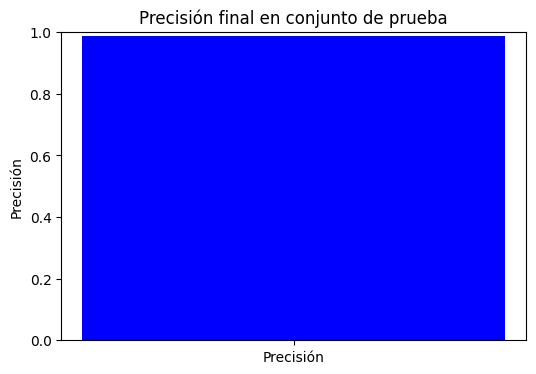

--------------------------------------------------------
--------------------------------------------------------
Total de ejemplos en prueba: 743
Etiquetas reales (prueba): [1, 0, 1, 0, 0, 0, 0, 0, 1, 0]
Predicciones (prueba): [1, 0, 1, 0, 0, 0, 0, 0, 1, 0]
------------------MATRIZ DE CONFUSIÓN--------------------


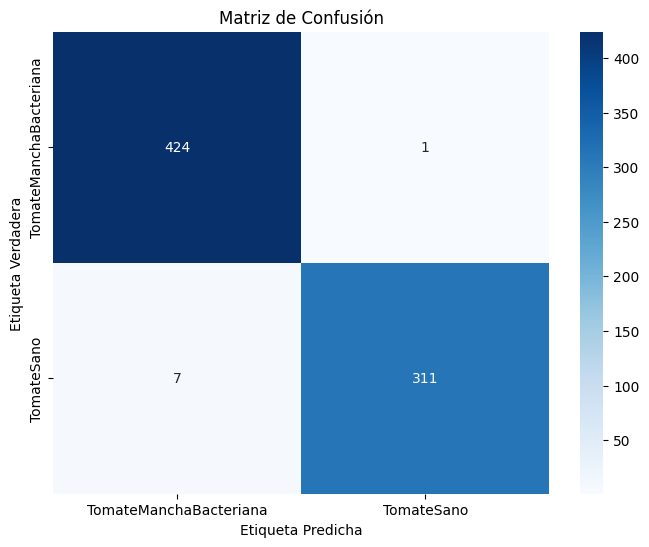

In [ ]:
model = torch.load('/content/drive/MyDrive/Colab Notebooks/TESIS/Modelos/Mod_Experimento4.pth')

test_data_root = '/content/drive/MyDrive/Colab Notebooks/TESIS/Datasets/val'

# Función para aplicar aumentos
def apply_augmentation(image):

    if random.random() < 0.5:
        transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
        ])
        image = transform(image)
    image = transforms.Resize((224, 224))(image)
    return image


class AugmentedImageFolder(torchvision.datasets.ImageFolder):
    def __getitem__(self, index):
        path, target = self.imgs[index]
        image = self.loader(path)
        image = apply_augmentation(image)
        if self.transform is not None:
            image = self.transform(image)
        return image, target


test_dataset = AugmentedImageFolder(root=test_data_root, transform=transforms.ToTensor())
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)



# Evaluación final en el conjunto de prueba
model.eval()
running_loss = 0.0
correct = 0
total = 0
all_labels = []
all_predictions = []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_loss = running_loss / total
test_accuracy = correct / total


print(f'Precisión en el conjunto de prueba: {test_accuracy* 100:.4f}%\n')
print(f'Pérdida en el conjunto de prueba: {test_loss* 100:.4f}%')

plt.figure(figsize=(6, 4))
plt.bar(['Precisión'], [test_accuracy], color='blue')
plt.ylim(0, 1)
plt.ylabel('Precisión')
plt.title('Precisión final en conjunto de prueba')
plt.show()

print('--------------------------------------------------------')
print('--------------------------------------------------------')


print(f"Total de ejemplos en prueba: {len(test_loader.dataset)}")
print(f"Etiquetas reales (prueba): {all_labels[:10]}")
print(f"Predicciones (prueba): {all_predictions[:10]}")

print('------------------MATRIZ DE CONFUSIÓN--------------------')

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.title('Matriz de Confusión')
    plt.show()

class_names = train_loader.dataset.dataset.classes
# Matriz de Confusión final
cm = confusion_matrix(all_labels, all_predictions)
plot_confusion_matrix(cm, class_names)

In [ ]:
from sklearn.metrics import accuracy_score
# Calcular la precisión global
accuracy = accuracy_score(all_labels, all_predictions)
print(f'Precisión global en el conjunto de prueba: {accuracy * 100:.2f}%')

Precisión global en el conjunto de prueba: 98.92%


.



.

.



.

-

.